# 1. Libraries and setup

We will train a **conditional diffusion model** on paired MNIST data:

$$
(x_{0,i},c_i),
$$

where:

- $x_{0,i}$ is a clean handwritten digit image,
- $c_i\in\{0,\ldots,9\}$ is its digit label.

The forward diffusion process will corrupt only the image:

$$
x_{0,i}\longrightarrow x_t.
$$

The digit label remains unchanged and is given to the score network:

$$
s_\theta(x_t,t,c_i).
$$

During generation, we choose a desired digit condition:

$$
c_{\mathrm{desired}},
$$

start from Gaussian noise:

$$
x_T^{\mathrm{new}}\sim\mathcal N(0,I),
$$

and run the reverse process using:

$$
s_\theta(x_t^{\mathrm{new}},t,c_{\mathrm{desired}}).
$$

In [1]:
# ── 1. Libraries and setup ────────────────────────────────────────────────────

import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

from torchvision import datasets, transforms


# ── Reproducibility ───────────────────────────────────────────────────────────

SEED = 42


def set_seed(seed: int = SEED) -> None:
    """Set random seeds for reproducible notebook results."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()


# ── Device ────────────────────────────────────────────────────────────────────
# Use Apple Silicon GPU when available.

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")


# ── Output directory ──────────────────────────────────────────────────────────

FIG_DIR = Path("figures_conditional_diffusion_mnist")
FIG_DIR.mkdir(parents=True, exist_ok=True)


# ── Plot settings ─────────────────────────────────────────────────────────────

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

Using device: cuda
PyTorch version: 2.3.1


# 2. Load paired MNIST data

For conditional diffusion, each training example is a pair:

$$
(x_{0,i},c_i),
$$

where:

- $x_{0,i}$ is a clean MNIST digit image,
- $c_i\in\{0,\ldots,9\}$ is the digit label associated with that image.

For example:

$$
(x_{0,i},c_i)
=
(\text{image of a handwritten 7},\,7).
$$

The forward diffusion process will add noise only to the image:

$$
x_{0,i}\longrightarrow x_t.
$$

The condition $c_i$ is not noised. It will later be given to the score network:

$$
s_\theta(x_t,t,c_i).
$$

We transform MNIST pixels from $[0,1]$ to:

$$
[-1,1],
$$

so that the clean data are centered around zero before the variance-preserving diffusion process gradually moves them toward Gaussian noise.

Full training dataset: 60,000 paired examples
Test dataset:          10,000 paired examples

Clean image shape: (1, 28, 28)
Condition c_i:      5
Normalized pixel range: [-1.00, 1.00]


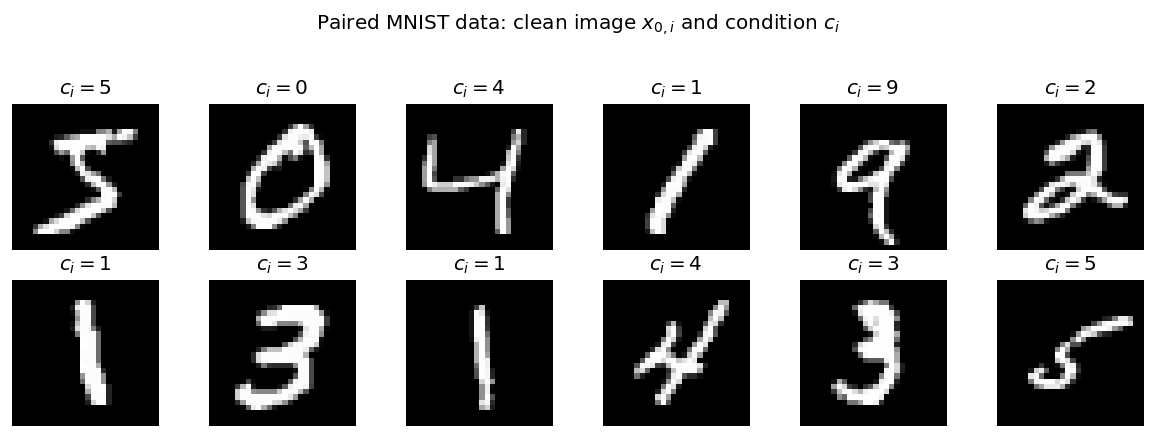

In [2]:
# ── 2. Load paired MNIST data ─────────────────────────────────────────────────

from pathlib import Path

import matplotlib.pyplot as plt
from torchvision import datasets, transforms


# ── Dataset location ──────────────────────────────────────────────────────────

DATA_DIR = Path("data")


# ── MNIST transform ───────────────────────────────────────────────────────────
# Step 1: ToTensor converts pixels from [0, 255] to floating-point values in [0, 1].
# Step 2: Normalize maps [0, 1] to [-1, 1]:
#
#     x_normalized = (x - 0.5) / 0.5 = 2x - 1

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5,), std=(0.5,)),
    ]
)


# ── Load paired MNIST datasets ────────────────────────────────────────────────
# Each dataset item is:
#
#     (x_0_i, c_i)
#
# where:
#     x_0_i : clean normalized image, shape (1, 28, 28), values approximately in [-1, 1]
#     c_i   : digit label / condition, integer in {0, ..., 9}

train_dataset_full = datasets.MNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform,
)


# ── Inspect one paired example ─────────────────────────────────────────────────

print(f"Full training dataset: {len(train_dataset_full):,} paired examples")
print(f"Test dataset:          {len(test_dataset):,} paired examples")

x0_example, c_example = train_dataset_full[0]

print(f"\nClean image shape: {tuple(x0_example.shape)}")
print(f"Condition c_i:      {c_example}")
print(
    "Normalized pixel range: "
    f"[{x0_example.min().item():.2f}, {x0_example.max().item():.2f}]"
)


# ── Helper: convert normalized images back to display values in [0, 1] ─────────

def denormalize_mnist(x: torch.Tensor) -> torch.Tensor:
    """
    Convert MNIST values from [-1, 1] back to [0, 1] for visualization.
    """
    return ((x + 1.0) / 2.0).clamp(0.0, 1.0)


# ── Visualize paired examples ─────────────────────────────────────────────────

N_SHOW = 12

fig, axes = plt.subplots(2, 6, figsize=(10, 3.5))

for ax, idx in zip(axes.flat, range(N_SHOW)):
    x0_i, c_i = train_dataset_full[idx]

    x_display = denormalize_mnist(x0_i)

    ax.imshow(x_display.squeeze(0), cmap="gray", vmin=0, vmax=1)
    ax.set_title(rf"$c_i={c_i}$")
    ax.axis("off")

fig.suptitle(
    "Paired MNIST data: clean image $x_{0,i}$ and condition $c_i$",
    y=1.03,
)

plt.tight_layout()
plt.show()

# 3. Train / validation split and DataLoaders

We split the paired MNIST data into training and validation sets.

Each example remains paired:

$$
(x_{0,i},c_i).
$$

Each mini-batch returned by the DataLoader contains:

$$
x_{0,\mathrm{batch}}
\in
\mathbb R^{B\times1\times28\times28}
$$

and

$$
c_{\mathrm{batch}}
\in
\{0,\ldots,9\}^{B}.
$$

The image batch will be noised during training.

The condition batch is not noised. Later, it will be supplied to the conditional score network:

$$
s_\theta(x_t,t,c).
$$

In [3]:
# ── 3. Train / validation split and DataLoaders ───────────────────────────────

from torch.utils.data import DataLoader, random_split


# ── Split paired training data ────────────────────────────────────────────────
# random_split preserves each dataset item:
#
#     (x_0_i, c_i)
#
# so every MNIST image remains paired with its correct digit condition.

N_VALID = 5_000
N_TRAIN = len(train_dataset_full) - N_VALID

split_generator = torch.Generator().manual_seed(SEED)

train_dataset, valid_dataset = random_split(
    train_dataset_full,
    lengths=[N_TRAIN, N_VALID],
    generator=split_generator,
)

print(f"Training examples:   {len(train_dataset):,}")
print(f"Validation examples: {len(valid_dataset):,}")
print(f"Test examples:       {len(test_dataset):,}")


# ── DataLoaders ───────────────────────────────────────────────────────────────
# num_workers=0 is the safest setting for macOS notebook execution.

BATCH_SIZE = 256
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)


# ── Inspect one paired mini-batch ─────────────────────────────────────────────

x0_batch, c_batch = next(iter(train_loader))

print("\nOne training mini-batch:")
print(f"x0_batch shape: {tuple(x0_batch.shape)}")
print(f"c_batch shape:  {tuple(c_batch.shape)}")
print(f"First 20 conditions: {c_batch[:20].tolist()}")

print(
    "\nPixel range in this normalized batch: "
    f"[{x0_batch.min().item():.2f}, {x0_batch.max().item():.2f}]"
)

assert x0_batch.shape == (BATCH_SIZE, 1, 28, 28)
assert c_batch.shape == (BATCH_SIZE,)
assert torch.all((c_batch >= 0) & (c_batch <= 9))

print("\nEach image in x0_batch remains paired with its digit condition in c_batch.")

Training examples:   55,000
Validation examples: 5,000
Test examples:       10,000

One training mini-batch:
x0_batch shape: (256, 1, 28, 28)
c_batch shape:  (256,)
First 20 conditions: [3, 1, 5, 0, 0, 8, 1, 1, 1, 6, 1, 9, 0, 1, 0, 2, 5, 0, 1, 8]

Pixel range in this normalized batch: [-1.00, 1.00]

Each image in x0_batch remains paired with its digit condition in c_batch.


# 4. Define the fixed VP forward process

The forward diffusion process is exactly the same as in the unconditional model.

For each clean image:

$$
x_{0,i},
$$

we choose a noise level:

$$
t_i\in\{1,\ldots,T\},
$$

sample Gaussian noise:

$$
\epsilon_i\sim\mathcal N(0,I),
$$

and create a noisy image:

$$
x_{t_i}
=
\sqrt{\bar\alpha_{t_i}}\,x_{0,i}
+
\sqrt{1-\bar\alpha_{t_i}}\,\epsilon_i.
$$

The variance-preserving schedule is defined by:

$$
\alpha_t=1-\beta_t,
\qquad
\bar\alpha_t=\prod_{s=1}^{t}\alpha_s.
$$

The condition is not noised:

$$
(x_{0,i},c_i)
\quad\longrightarrow\quad
(x_{t_i},c_i).
$$

Only the image changes from $x_{0,i}$ to $x_{t_i}$.

Later, the score network will receive:

$$
s_\theta(x_{t_i},t_i,c_i).
$$

Number of diffusion steps T: 1000
Beta range: [0.000100, 0.020000]
alpha_bar_0: 1.000000
alpha_bar_T: 0.000040


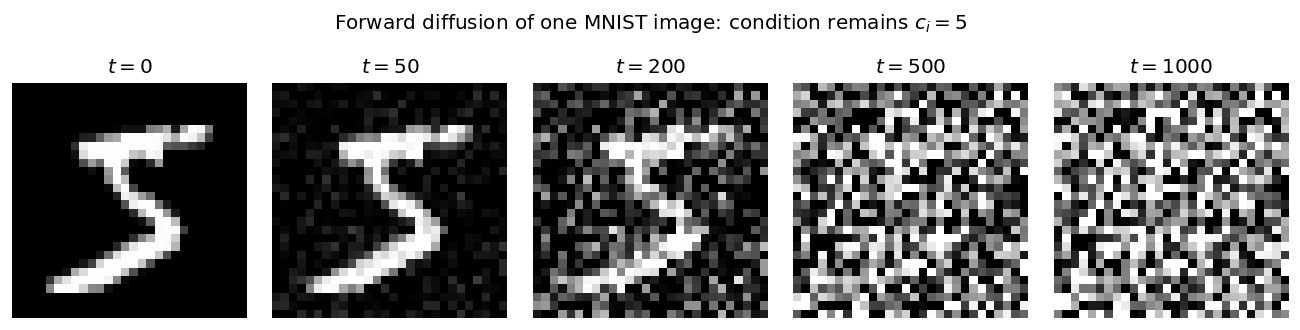

In [5]:
# ── 4. Fixed variance-preserving forward process ──────────────────────────────

# We use a discrete variance-preserving (VP) diffusion process.
#
# At each step:
#
#     x_t = sqrt(1 - beta_t) * x_{t-1} + sqrt(beta_t) * epsilon_t
#
# The closed-form expression lets us jump directly from x_0 to any x_t:
#
#     x_t = sqrt(alpha_bar_t) * x_0
#           + sqrt(1 - alpha_bar_t) * epsilon


# ── Diffusion schedule ────────────────────────────────────────────────────────

T_DIFF = 1_000

BETA_START = 1e-4
BETA_END = 2e-2

# beta_t for t = 1, ..., T_DIFF
BETAS = torch.linspace(
    BETA_START,
    BETA_END,
    T_DIFF,
    dtype=torch.float32,
)

# alpha_t = 1 - beta_t
ALPHAS = 1.0 - BETAS

# alpha_bar_t = product_{s=1}^t alpha_s
#
# We prepend alpha_bar_0 = 1 so that:
#
#     x_{t=0} = x_0
#
# and t can naturally range from 0 to T_DIFF.

ALPHA_BARS = torch.cat(
    [
        torch.ones(1, dtype=torch.float32),
        torch.cumprod(ALPHAS, dim=0),
    ]
)

print(f"Number of diffusion steps T: {T_DIFF}")
print(f"Beta range: [{BETAS[0].item():.6f}, {BETAS[-1].item():.6f}]")
print(f"alpha_bar_0: {ALPHA_BARS[0].item():.6f}")
print(f"alpha_bar_T: {ALPHA_BARS[-1].item():.6f}")


# ── Helper: select schedule values for every item in a batch ──────────────────

def extract_schedule_values(
    values: torch.Tensor,
    t: torch.Tensor,
    x_shape: tuple[int, ...],
) -> torch.Tensor:
    """
    Select one schedule value for each element of a mini-batch.

    Parameters
    ----------
    values
        One-dimensional tensor containing schedule values.
        Here, values will be ALPHA_BARS.

    t
        Integer noise levels with shape (batch_size,).

    x_shape
        Shape of the image batch, for example:
            (batch_size, 1, 28, 28)

    Returns
    -------
    selected_values
        Tensor with shape:
            (batch_size, 1, 1, 1)

        This broadcasts correctly over all image pixels.
    """
    selected_values = values.to(t.device)[t]

    return selected_values.view(
        t.shape[0],
        *([1] * (len(x_shape) - 1)),
    )


# ── Closed-form forward noising function ──────────────────────────────────────

def q_sample(
    x0: torch.Tensor,
    t: torch.Tensor,
    noise: torch.Tensor | None = None,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Sample x_t directly from q(x_t | x_0).

    x_t = sqrt(alpha_bar_t) * x_0
          + sqrt(1 - alpha_bar_t) * epsilon

    Parameters
    ----------
    x0
        Clean normalized MNIST images with shape:
            (batch_size, 1, 28, 28)

    t
        Integer noise levels in {0, ..., T_DIFF},
        with shape:
            (batch_size,)

    noise
        Optional Gaussian noise with the same shape as x0.
        If omitted, fresh Gaussian noise is sampled.

    Returns
    -------
    xt
        Noisy images with the same shape as x0.

    noise
        The Gaussian noise used to create xt.
    """
    if noise is None:
        noise = torch.randn_like(x0)

    alpha_bar_t = extract_schedule_values(
        values=ALPHA_BARS,
        t=t,
        x_shape=tuple(x0.shape),
    )

    xt = (
        torch.sqrt(alpha_bar_t) * x0
        + torch.sqrt(1.0 - alpha_bar_t) * noise
    )

    return xt, noise


# ── Visualize one image at increasing noise levels ────────────────────────────

x0_example, c_example = train_dataset_full[0]

x0_example = x0_example.unsqueeze(0).to(DEVICE)

# Use the same epsilon at every time point.
# This makes the gradual forward trajectory easier to see.
fixed_noise = torch.randn_like(x0_example)

TIMES_TO_SHOW = [0, 50, 200, 500, T_DIFF]

fig, axes = plt.subplots(
    1,
    len(TIMES_TO_SHOW),
    figsize=(2.2 * len(TIMES_TO_SHOW), 2.6),
)

for ax, t_value in zip(axes, TIMES_TO_SHOW):

    t_tensor = torch.tensor(
        [t_value],
        dtype=torch.long,
        device=DEVICE,
    )

    xt_example, _ = q_sample(
        x0=x0_example,
        t=t_tensor,
        noise=fixed_noise,
    )

    # The diffusion process acts on normalized values.
    # Convert back to [0, 1] only for display.
    xt_display = denormalize_mnist(
        xt_example.detach().cpu().squeeze(0)
    )

    ax.imshow(
        xt_display.squeeze(0),
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    ax.set_title(rf"$t={t_value}$")
    ax.axis("off")

fig.suptitle(
    rf"Forward diffusion of one MNIST image: condition remains $c_i={c_example}$",
    y=1.04,
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "conditional_diffusion_forward_process.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

# 5. Build a conditional U-Net score network

MNIST images have spatial structure:

$$
x_t\in\mathbb{R}^{1\times28\times28}.
$$

So, instead of a fully connected network, we use a small **conditional U-Net**.

The U-Net first compresses the noisy image into lower-resolution feature maps, then expands back to the original image size:

$$
x_t
\longrightarrow
\text{down path}
\longrightarrow
\text{bottleneck}
\longrightarrow
\text{up path}
\longrightarrow
s_\theta(x_t,t,c).
$$

Skip connections carry local spatial information from the down path to the matching up path.

The network receives:

$$
(x_t,t,c),
$$

where:

- $x_t$ is the noisy image,
- $t$ is the noise level,
- $c\in\{0,\ldots,9\}$ is the requested digit condition.

We convert both $t$ and $c$ into embedding vectors and supply them throughout the U-Net.

The network returns a score image with the same shape as the noisy input:

$$
s_\theta(x_t,t,c)
\in
\mathbb{R}^{1\times28\times28}.
$$

It learns to approximate the conditional score:

$$
s_\theta(x_t,t,c)
\approx
\nabla_{x_t}\log p_t(x_t\mid c).
$$

In [6]:
# ── 5. Conditional U-Net score network ───────────────────────────────────────

import math

# ── Architecture hyperparameters ──────────────────────────────────────────────

N_CLASSES = 10

BASE_CHANNELS = 32
TIME_EMBED_DIM = 128
LABEL_EMBED_DIM = 128


# ── Time embedding ───────────────────────────────────────────────────────────

class SinusoidalTimeEmbedding(nn.Module):
    """
    Convert a diffusion time t into a deterministic sinusoidal vector.

    Input:
        t : shape (batch_size,)

    Output:
        embedding : shape (batch_size, embedding_dim)
    """

    def __init__(self, embedding_dim: int):
        super().__init__()

        if embedding_dim % 2 != 0:
            raise ValueError("embedding_dim must be even.")

        self.embedding_dim = embedding_dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        half_dim = self.embedding_dim // 2

        frequencies = torch.exp(
            -math.log(10_000.0)
            * torch.arange(
                half_dim,
                device=t.device,
                dtype=torch.float32,
            )
            / (half_dim - 1)
        )

        angles = t.float().unsqueeze(1) * frequencies.unsqueeze(0)

        return torch.cat(
            [
                torch.sin(angles),
                torch.cos(angles),
            ],
            dim=1,
        )


# ── Conditional residual block ────────────────────────────────────────────────

class ConditionalResBlock(nn.Module):
    """
    A residual convolutional block conditioned on one embedding vector.

    The embedding contains information about both:

        - diffusion time t
        - digit condition c

    It is projected to one value per output channel and added to the
    intermediate feature map.
    """

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        embedding_dim: int,
        n_groups: int = 8,
    ):
        super().__init__()

        self.norm1 = nn.GroupNorm(
            num_groups=n_groups,
            num_channels=in_channels,
        )
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1,
        )

        self.embedding_projection = nn.Sequential(
            nn.SiLU(),
            nn.Linear(embedding_dim, out_channels),
        )

        self.norm2 = nn.GroupNorm(
            num_groups=n_groups,
            num_channels=out_channels,
        )
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1,
        )

        if in_channels == out_channels:
            self.skip_connection = nn.Identity()
        else:
            self.skip_connection = nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
            )

    def forward(
        self,
        x: torch.Tensor,
        embedding: torch.Tensor,
    ) -> torch.Tensor:
        residual = self.skip_connection(x)

        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)

        # Convert one embedding vector per image into one value per channel:
        #
        #   (batch_size, embedding_dim)
        #       ->
        #   (batch_size, out_channels, 1, 1)
        #
        # Broadcasting then adds this condition-dependent value at every
        # spatial location in that feature channel.
        embedding_channels = self.embedding_projection(embedding)
        embedding_channels = embedding_channels[:, :, None, None]

        h = h + embedding_channels

        h = self.norm2(h)
        h = F.silu(h)
        h = self.conv2(h)

        return h + residual


# ── Conditional U-Net ─────────────────────────────────────────────────────────

class ConditionalUNet(nn.Module):
    """
    Small U-Net for conditional MNIST diffusion.

    Input:
        x_t : noisy image, shape (batch_size, 1, 28, 28)
        t   : diffusion time, shape (batch_size,)
        c   : digit condition, shape (batch_size,)

    Output:
        predicted score image, shape (batch_size, 1, 28, 28)
    """

    def __init__(
        self,
        n_classes: int = N_CLASSES,
        base_channels: int = BASE_CHANNELS,
        time_embed_dim: int = TIME_EMBED_DIM,
        label_embed_dim: int = LABEL_EMBED_DIM,
    ):
        super().__init__()

        if time_embed_dim != label_embed_dim:
            raise ValueError(
                "time_embed_dim and label_embed_dim must match "
                "so that their embeddings can be added."
            )

        # ── Time and condition embeddings ─────────────────────────────────────

        self.time_embedding = nn.Sequential(
            SinusoidalTimeEmbedding(time_embed_dim),
            nn.Linear(time_embed_dim, time_embed_dim),
            nn.SiLU(),
            nn.Linear(time_embed_dim, time_embed_dim),
        )

        self.label_embedding = nn.Embedding(
            num_embeddings=n_classes,
            embedding_dim=label_embed_dim,
        )

        # ── Down path: 28×28 -> 14×14 -> 7×7 ──────────────────────────────────

        self.input_conv = nn.Conv2d(
            in_channels=1,
            out_channels=base_channels,
            kernel_size=3,
            padding=1,
        )

        self.down_block_1 = ConditionalResBlock(
            in_channels=base_channels,
            out_channels=base_channels,
            embedding_dim=time_embed_dim,
        )

        self.downsample_1 = nn.Conv2d(
            in_channels=base_channels,
            out_channels=2 * base_channels,
            kernel_size=3,
            stride=2,
            padding=1,
        )

        self.down_block_2 = ConditionalResBlock(
            in_channels=2 * base_channels,
            out_channels=2 * base_channels,
            embedding_dim=time_embed_dim,
        )

        self.downsample_2 = nn.Conv2d(
            in_channels=2 * base_channels,
            out_channels=4 * base_channels,
            kernel_size=3,
            stride=2,
            padding=1,
        )

        # ── Bottleneck: 7×7 ──────────────────────────────────────────────────

        self.middle_block_1 = ConditionalResBlock(
            in_channels=4 * base_channels,
            out_channels=4 * base_channels,
            embedding_dim=time_embed_dim,
        )

        self.middle_block_2 = ConditionalResBlock(
            in_channels=4 * base_channels,
            out_channels=4 * base_channels,
            embedding_dim=time_embed_dim,
        )

        # ── Up path: 7×7 -> 14×14 -> 28×28 ───────────────────────────────────

        self.upsample_1 = nn.ConvTranspose2d(
            in_channels=4 * base_channels,
            out_channels=2 * base_channels,
            kernel_size=4,
            stride=2,
            padding=1,
        )

        self.up_block_1 = ConditionalResBlock(
            in_channels=4 * base_channels,
            out_channels=2 * base_channels,
            embedding_dim=time_embed_dim,
        )

        self.upsample_2 = nn.ConvTranspose2d(
            in_channels=2 * base_channels,
            out_channels=base_channels,
            kernel_size=4,
            stride=2,
            padding=1,
        )

        self.up_block_2 = ConditionalResBlock(
            in_channels=2 * base_channels,
            out_channels=base_channels,
            embedding_dim=time_embed_dim,
        )

        # ── Output layer ──────────────────────────────────────────────────────

        self.output_norm = nn.GroupNorm(
            num_groups=8,
            num_channels=base_channels,
        )

        self.output_conv = nn.Conv2d(
            in_channels=base_channels,
            out_channels=1,
            kernel_size=3,
            padding=1,
        )

    def forward(
        self,
        xt: torch.Tensor,
        t: torch.Tensor,
        c: torch.Tensor,
    ) -> torch.Tensor:
        # Build one shared conditioning embedding for each image:
        #
        #   e = e_time(t) + e_label(c)
        #
        # This combined embedding is supplied to every residual block.

        time_embedding = self.time_embedding(t)
        label_embedding = self.label_embedding(c)

        embedding = time_embedding + label_embedding

        # ── Down path ─────────────────────────────────────────────────────────

        h0 = self.input_conv(xt)

        h1 = self.down_block_1(h0, embedding)
        h2 = self.downsample_1(h1)

        h3 = self.down_block_2(h2, embedding)
        h4 = self.downsample_2(h3)

        # ── Bottleneck ────────────────────────────────────────────────────────

        h = self.middle_block_1(h4, embedding)
        h = self.middle_block_2(h, embedding)

        # ── Up path with skip connections ─────────────────────────────────────

        h = self.upsample_1(h)
        h = torch.cat([h, h3], dim=1)
        h = self.up_block_1(h, embedding)

        h = self.upsample_2(h)
        h = torch.cat([h, h1], dim=1)
        h = self.up_block_2(h, embedding)

        # ── Predicted conditional score image ─────────────────────────────────

        h = self.output_norm(h)
        h = F.silu(h)

        return self.output_conv(h)


# ── Create the model ──────────────────────────────────────────────────────────

score_model = ConditionalUNet().to(DEVICE)

n_parameters = sum(
    parameter.numel()
    for parameter in score_model.parameters()
    if parameter.requires_grad
)

print(score_model)
print(f"\nTrainable parameters: {n_parameters:,}")


# ── Shape check ───────────────────────────────────────────────────────────────

x0_batch, c_batch = next(iter(train_loader))

x0_batch = x0_batch.to(DEVICE)
c_batch = c_batch.to(DEVICE)

t_batch = torch.randint(
    low=0,
    high=T_DIFF + 1,
    size=(x0_batch.shape[0],),
    device=DEVICE,
)

xt_batch, _ = q_sample(
    x0=x0_batch,
    t=t_batch,
)

score_model.eval()

with torch.no_grad():
    score_prediction = score_model(
        xt=xt_batch,
        t=t_batch,
        c=c_batch,
    )

print("\nShape check:")
print(f"x_t shape:               {tuple(xt_batch.shape)}")
print(f"condition batch shape:   {tuple(c_batch.shape)}")
print(f"predicted score shape:   {tuple(score_prediction.shape)}")

assert score_prediction.shape == xt_batch.shape

print("\nThe conditional U-Net returns one predicted score value per image pixel.")

ConditionalUNet(
  (time_embedding): Sequential(
    (0): SinusoidalTimeEmbedding()
    (1): Linear(in_features=128, out_features=128, bias=True)
    (2): SiLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
  )
  (label_embedding): Embedding(10, 128)
  (input_conv): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (down_block_1): ConditionalResBlock(
    (norm1): GroupNorm(8, 32, eps=1e-05, affine=True)
    (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (embedding_projection): Sequential(
      (0): SiLU()
      (1): Linear(in_features=128, out_features=32, bias=True)
    )
    (norm2): GroupNorm(8, 32, eps=1e-05, affine=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (skip_connection): Identity()
  )
  (downsample_1): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (down_block_2): ConditionalResBlock(
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
    

# 6. Calculate the known per-example score targets

For each paired training example:

$$
(x_0^{(b)},c^{(b)}),
$$

we diffuse only the image and obtain:

$$
x_{t^{(b)}}^{(b)}.
$$

The condition $c^{(b)}$ does not change the forward Gaussian blob:

$$
q_{t^{(b)}}
\left(
x_{t^{(b)}}^{(b)}
\mid
x_0^{(b)}
\right).
$$

Therefore, the known target score is the same Gaussian-blob score as before:

$$
a^{(b)}
=
\nabla_{x_{t^{(b)}}^{(b)}}
\log
q_{t^{(b)}}
\left(
x_{t^{(b)}}^{(b)}
\mid
x_0^{(b)}
\right).
$$

Because:

$$
q_t(x_t\mid x_0)
=
\mathcal N
\left(
\sqrt{\bar\alpha_t}x_0,
(1-\bar\alpha_t)I
\right),
$$

its score is:

$$
a^{(b)}
=
\frac{
\sqrt{\bar\alpha_{t^{(b)}}}x_0^{(b)}
-
x_{t^{(b)}}^{(b)}
}{
1-\bar\alpha_{t^{(b)}}
}.
$$

Using:

$$
x_t
=
\sqrt{\bar\alpha_t}x_0
+
\sqrt{1-\bar\alpha_t}\epsilon,
$$

we can compute the same target more directly as:

$$
a^{(b)}
=
-\frac{\epsilon^{(b)}}
{\sqrt{1-\bar\alpha_{t^{(b)}}}}.
$$

The target arrow itself does not receive $c^{(b)}$.

Instead, the condition tells the network which conditional population this example belongs to:

$$
s_\theta(x_t,t,c)
\approx
\nabla_{x_t}\log p_t(x_t\mid c).
$$

In [7]:
# ── 6. Known per-example Gaussian-blob score targets ─────────────────────────

def gaussian_blob_score_target(
    x0: torch.Tensor,
    xt: torch.Tensor,
    t: torch.Tensor,
) -> torch.Tensor:
    """
    Compute the exact score of the known forward Gaussian blob:

        q_t(x_t | x_0)
        =
        N(
            sqrt(alpha_bar_t) * x_0,
            (1 - alpha_bar_t) * I
        )

    The score target is:

        a
        =
        grad_{x_t} log q_t(x_t | x_0)

        =
        [sqrt(alpha_bar_t) * x_0 - x_t]
        /
        [1 - alpha_bar_t]

    Parameters
    ----------
    x0
        Clean MNIST images with shape:
            (batch_size, 1, 28, 28)

    xt
        Noisy MNIST images with the same shape as x0.

    t
        Integer diffusion times with shape:
            (batch_size,)

        During training, t must lie in {1, ..., T_DIFF}.
        We do not train at t = 0 because the Gaussian variance is zero there.

    Returns
    -------
    target
        Exact per-example Gaussian-blob score target,
        with the same shape as x0 and xt.
    """
    if torch.any(t < 1):
        raise ValueError(
            "Score targets are undefined at t = 0. "
            "Use diffusion times in {1, ..., T_DIFF} during training."
        )

    alpha_bar_t = extract_schedule_values(
        values=ALPHA_BARS,
        t=t,
        x_shape=tuple(x0.shape),
    )

    target = (
        torch.sqrt(alpha_bar_t) * x0 - xt
    ) / (
        1.0 - alpha_bar_t
    )

    return target


# ── Check the target formula on one mini-batch ─────────────────────────────────
# For this check, choose t in {1, ..., T_DIFF}.
# The model will later learn from these exact target arrows.

x0_batch, c_batch = next(iter(train_loader))

x0_batch = x0_batch.to(DEVICE)
c_batch = c_batch.to(DEVICE)

batch_size = x0_batch.shape[0]

t_batch = torch.randint(
    low=1,
    high=T_DIFF + 1,
    size=(batch_size,),
    device=DEVICE,
)

xt_batch, noise_batch = q_sample(
    x0=x0_batch,
    t=t_batch,
)

target_from_gaussian = gaussian_blob_score_target(
    x0=x0_batch,
    xt=xt_batch,
    t=t_batch,
)


# ── Equivalent numerically stable form ────────────────────────────────────────
#
# Since:
#
#     x_t = sqrt(alpha_bar_t) * x_0
#           + sqrt(1 - alpha_bar_t) * epsilon,
#
# the Gaussian-blob score target is also:
#
#     a = -epsilon / sqrt(1 - alpha_bar_t)

alpha_bar_t = extract_schedule_values(
    values=ALPHA_BARS,
    t=t_batch,
    x_shape=tuple(x0_batch.shape),
)

target_from_noise = -noise_batch / torch.sqrt(1.0 - alpha_bar_t)

maximum_difference = (
    target_from_gaussian - target_from_noise
).abs().max().item()

print("Target shape:", tuple(target_from_gaussian.shape))
print(f"Maximum difference between the two target formulas: {maximum_difference:.3e}")

assert target_from_gaussian.shape == x0_batch.shape
assert torch.allclose(
    target_from_gaussian,
    target_from_noise,
    atol=1e-5,
    rtol=1e-4,
)

print("\nThe two expressions give the same per-example score target.")
print("The label c_batch is kept for the conditional score network in the next block.")

Target shape: (256, 1, 28, 28)
Maximum difference between the two target formulas: 5.722e-05

The two expressions give the same per-example score target.
The label c_batch is kept for the conditional score network in the next block.


# 7. Define the variance-weighted conditional score-matching loss

For each example in a paired mini-batch:

$$
\left(x_0^{(b)},c^{(b)}\right),
$$

we create a noisy image:

$$
x_{t^{(b)}}^{(b)},
$$

calculate its known Gaussian-blob score target:

$$
a^{(b)},
$$

and ask the conditional U-Net to predict:

$$
\hat a^{(b)}
=
s_\theta
\left(
x_{t^{(b)}}^{(b)},
t^{(b)},
c^{(b)}
\right).
$$

The squared score-matching error for one example is:

$$
\left\|
\hat a^{(b)}-a^{(b)}
\right\|^2.
$$

At small noise levels, the Gaussian blob is extremely narrow and its score can become very large.

We therefore use the variance-weighted loss:

$$
\ell^{(b)}(\theta)
=
\left(
1-\bar\alpha_{t^{(b)}}
\right)
\left\|
\hat a^{(b)}-a^{(b)}
\right\|^2.
$$

For a mini-batch of size $B$:

$$
\mathcal L_{\mathrm{batch}}(\theta)
=
\frac{1}{B}
\sum_{b=1}^{B}
\left(
1-\bar\alpha_{t^{(b)}}
\right)
\left\|
s_\theta
\left(
x_{t^{(b)}}^{(b)},
t^{(b)},
c^{(b)}
\right)
-
a^{(b)}
\right\|^2.
$$

The condition enters through the network prediction:

$$
s_\theta(x_t,t,c).
$$

The known Gaussian-blob target remains unchanged.

In [8]:
# ── 7. Variance-weighted conditional score-matching loss ──────────────────────

def conditional_score_matching_loss(
    score_prediction: torch.Tensor,
    score_target: torch.Tensor,
    t: torch.Tensor,
) -> torch.Tensor:
    """
    Compute the variance-weighted direct score-matching loss.

    For each example b:

        loss_b
        =
        (1 - alpha_bar_t_b)
        *
        mean_over_pixels(
            || score_prediction_b - score_target_b ||^2
        )

    The batch loss is the mean of these per-example losses.

    Parameters
    ----------
    score_prediction
        Conditional U-Net output:

            s_theta(x_t, t, c)

        Shape:
            (batch_size, 1, 28, 28)

    score_target
        Exact Gaussian-blob score target:

            grad_{x_t} log q_t(x_t | x_0)

        Shape:
            (batch_size, 1, 28, 28)

    t
        Integer diffusion times in {1, ..., T_DIFF},
        shape:
            (batch_size,)

    Returns
    -------
    loss
        Scalar tensor.
    """
    if score_prediction.shape != score_target.shape:
        raise ValueError(
            "score_prediction and score_target must have the same shape. "
            f"Got {tuple(score_prediction.shape)} and "
            f"{tuple(score_target.shape)}."
        )

    alpha_bar_t = extract_schedule_values(
        values=ALPHA_BARS,
        t=t,
        x_shape=tuple(score_prediction.shape),
    )

    # One squared-error value per pixel.
    squared_error = (score_prediction - score_target).pow(2)

    # Average over image channels and pixels, leaving one loss per example:
    #
    #     shape: (batch_size,)
    #
    per_example_mse = squared_error.mean(dim=(1, 2, 3))

    # alpha_bar_t has shape (batch_size, 1, 1, 1).
    # Flatten it so there is one scalar weight per example.
    variance_weight = (1.0 - alpha_bar_t).view(-1)

    per_example_loss = variance_weight * per_example_mse

    return per_example_loss.mean()


# ── Test the loss on one mini-batch ───────────────────────────────────────────

score_model.train()

x0_batch, c_batch = next(iter(train_loader))

x0_batch = x0_batch.to(DEVICE)
c_batch = c_batch.to(DEVICE)

batch_size = x0_batch.shape[0]

# We train only at positive noise times because the score target is undefined at t = 0.
t_batch = torch.randint(
    low=1,
    high=T_DIFF + 1,
    size=(batch_size,),
    device=DEVICE,
)

xt_batch, _ = q_sample(
    x0=x0_batch,
    t=t_batch,
)

score_target = gaussian_blob_score_target(
    x0=x0_batch,
    xt=xt_batch,
    t=t_batch,
)

score_prediction = score_model(
    xt=xt_batch,
    t=t_batch,
    c=c_batch,
)

loss = conditional_score_matching_loss(
    score_prediction=score_prediction,
    score_target=score_target,
    t=t_batch,
)

print(f"Conditional score-matching loss: {loss.item():.6f}")

assert loss.ndim == 0
assert torch.isfinite(loss)

print("\nThe loss is a finite scalar and is ready for optimization.")

Conditional score-matching loss: 1.027970

The loss is a finite scalar and is ready for optimization.


# 8. Train the conditional diffusion model

For every paired mini-batch:

$$
\left\{
\left(x_0^{(b)},c^{(b)}\right)
\right\}_{b=1}^{B},
$$

we:

### A. Draw one noise level and one Gaussian noise image per example:

$$
t^{(b)}
\sim
\operatorname{Uniform}\{1,\ldots,T\},
\qquad
\epsilon^{(b)}
\sim
\mathcal N(0,I).
$$

### B. Noise the images while keeping their conditions unchanged:

$$
(x_0^{(b)},c^{(b)})
\longrightarrow
(x_{t^{(b)}}^{(b)},c^{(b)}).
$$

### C. Calculate the known per-example Gaussian-blob score target:

$$
a^{(b)}
=
-\frac{\epsilon^{(b)}}
{\sqrt{1-\bar\alpha_{t^{(b)}}}}.
$$

### D. Ask the conditional U-Net to predict:

$$
\hat a^{(b)}
=
s_\theta
\left(
x_{t^{(b)}}^{(b)},
t^{(b)},
c^{(b)}
\right).
$$

### E. Compute the variance-weighted score-matching loss:

$$
\mathcal L_{\mathrm{batch}}(\theta)
=
\frac{1}{B}
\sum_{b=1}^{B}
\left(
1-\bar\alpha_{t^{(b)}}
\right)
\left\|
\hat a^{(b)}-a^{(b)}
\right\|^2.
$$

### F. During training, backpropagate and update the U-Net parameters.

During validation, we perform the same forward calculation but do not update any parameters.

We save the model with the lowest validation loss.

Training for 20 epochs
Learning rate: 0.0002
Weight decay:  0.0001
Checkpoint:    figures_conditional_diffusion_mnist/conditional_mnist_score_unet_best.pt
Epoch 01/20 | train: 0.163302 | valid: 0.085184  ← saved best model
Epoch 02/20 | train: 0.072579 | valid: 0.061066  ← saved best model
Epoch 03/20 | train: 0.057233 | valid: 0.049897  ← saved best model
Epoch 04/20 | train: 0.049100 | valid: 0.049794  ← saved best model
Epoch 05/20 | train: 0.045353 | valid: 0.045386  ← saved best model
Epoch 06/20 | train: 0.042163 | valid: 0.038579  ← saved best model
Epoch 07/20 | train: 0.039603 | valid: 0.038478  ← saved best model
Epoch 08/20 | train: 0.036784 | valid: 0.036792  ← saved best model
Epoch 09/20 | train: 0.035659 | valid: 0.034515  ← saved best model
Epoch 10/20 | train: 0.035147 | valid: 0.035434
Epoch 11/20 | train: 0.033746 | valid: 0.034646
Epoch 12/20 | train: 0.032869 | valid: 0.033185  ← saved best model
Epoch 13/20 | train: 0.031970 | valid: 0.031130  ← saved best model
E

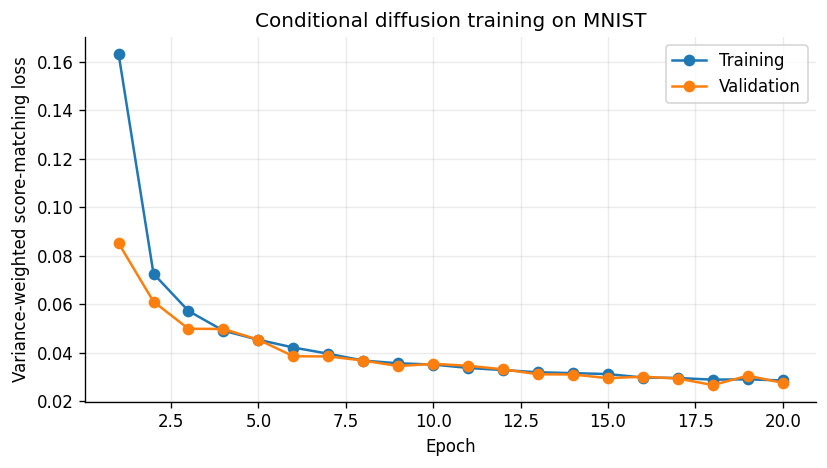

In [10]:
# ── 8. Train the conditional diffusion model ──────────────────────────────────

# ── 8.1 Training configuration ───────────────────────────────────────────────

N_EPOCHS = 20
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-4
MAX_GRAD_NORM = 1.0

MODEL_PATH = FIG_DIR / "conditional_mnist_score_unet_best.pt"

optimizer = torch.optim.AdamW(
    score_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

print(f"Training for {N_EPOCHS} epochs")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Weight decay:  {WEIGHT_DECAY}")
print(f"Checkpoint:    {MODEL_PATH}")


# ── 8.2 Stable Gaussian-blob score target ────────────────────────────────────

def score_target_from_noise(
    noise: torch.Tensor,
    t: torch.Tensor,
) -> torch.Tensor:
    """
    Calculate the exact per-example Gaussian-blob score target using:

        a = -epsilon / sqrt(1 - alpha_bar_t)

    This is equivalent to:

        a =
        [sqrt(alpha_bar_t) * x_0 - x_t]
        /
        [1 - alpha_bar_t]

    Parameters
    ----------
    noise
        Gaussian noise epsilon used in the forward process.
        Shape: (batch_size, 1, 28, 28)

    t
        Integer diffusion times in {1, ..., T_DIFF}.
        Shape: (batch_size,)

    Returns
    -------
    score_target
        Exact Gaussian-blob score target with the same shape as noise.
    """
    if torch.any(t < 1):
        raise ValueError(
            "The score target is undefined at t = 0. "
            "Use times from {1, ..., T_DIFF} during training."
        )

    alpha_bar_t = extract_schedule_values(
        values=ALPHA_BARS,
        t=t,
        x_shape=tuple(noise.shape),
    )

    score_target = -noise / torch.sqrt(1.0 - alpha_bar_t)

    return score_target


# ── 8.3 One training or validation epoch ──────────────────────────────────────

def run_conditional_diffusion_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    optimizer: torch.optim.Optimizer | None = None,
) -> float:
    """
    Run one conditional-diffusion training or validation epoch.

    Parameters
    ----------
    model
        Conditional U-Net score model.

    data_loader
        DataLoader returning paired mini-batches:

            (x0_batch, c_batch)

    optimizer
        When supplied, train the model.
        When None, evaluate without parameter updates.

    Returns
    -------
    mean_epoch_loss
        Mean variance-weighted score-matching loss over the epoch.
    """
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    n_examples = 0

    for x0_batch, c_batch in data_loader:

        # ── Take one paired mini-batch ───────────────────────────────────────

        x0_batch = x0_batch.to(DEVICE)
        c_batch = c_batch.to(DEVICE)

        batch_size = x0_batch.shape[0]

        # ── Draw one noise level and one Gaussian noise image per example ────
        #
        # We exclude t = 0 because the Gaussian-blob score target has
        # zero variance there and is therefore undefined.

        t_batch = torch.randint(
            low=1,
            high=T_DIFF + 1,
            size=(batch_size,),
            device=DEVICE,
        )

        xt_batch, noise_batch = q_sample(
            x0=x0_batch,
            t=t_batch,
        )

        # ── Calculate the exact Gaussian-blob score target ───────────────────

        score_target = score_target_from_noise(
            noise=noise_batch,
            t=t_batch,
        )

        # ── Predict conditional scores and calculate loss ────────────────────

        with torch.set_grad_enabled(is_training):

            score_prediction = model(
                xt=xt_batch,
                t=t_batch,
                c=c_batch,
            )

            loss = conditional_score_matching_loss(
                score_prediction=score_prediction,
                score_target=score_target,
                t=t_batch,
            )

            # ── Backpropagate and update only during training ────────────────

            if is_training:
                optimizer.zero_grad(set_to_none=True)

                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=MAX_GRAD_NORM,
                )

                optimizer.step()

        total_loss += loss.item() * batch_size
        n_examples += batch_size

    return total_loss / n_examples


# ── 8.4 Full training loop ────────────────────────────────────────────────────

history = {
    "train_loss": [],
    "valid_loss": [],
}

best_valid_loss = float("inf")
best_epoch = 0

for epoch in range(1, N_EPOCHS + 1):

    train_loss = run_conditional_diffusion_epoch(
        model=score_model,
        data_loader=train_loader,
        optimizer=optimizer,
    )

    valid_loss = run_conditional_diffusion_epoch(
        model=score_model,
        data_loader=valid_loader,
        optimizer=None,
    )

    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)

    # ── Save the best validation model ───────────────────────────────────────

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_epoch = epoch

        torch.save(
            score_model.state_dict(),
            MODEL_PATH,
        )

        checkpoint_message = "  ← saved best model"
    else:
        checkpoint_message = ""

    print(
        f"Epoch {epoch:02d}/{N_EPOCHS} | "
        f"train: {train_loss:.6f} | "
        f"valid: {valid_loss:.6f}"
        f"{checkpoint_message}"
    )


# ── 8.5 Restore the best validation model ─────────────────────────────────────

best_model_state = torch.load(
    MODEL_PATH,
    map_location=DEVICE,
)

score_model.load_state_dict(best_model_state)
score_model.to(DEVICE)
score_model.eval()

print("\nTraining complete.")
print(f"Best validation loss: {best_valid_loss:.6f}")
print(f"Best epoch:           {best_epoch}")


# ── 8.6 Plot training and validation losses ───────────────────────────────────

epochs = np.arange(1, N_EPOCHS + 1)

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Training",
)

ax.plot(
    epochs,
    history["valid_loss"],
    marker="o",
    label="Validation",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Variance-weighted score-matching loss")
ax.set_title("Conditional diffusion training on MNIST")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "conditional_diffusion_training_curve.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

# 9. Diagnostics after training



# 10. Load the trained conditional diffusion model

We load the trained conditional score model:

$$
s_\theta(x_t,t,c)
\approx
\nabla_{x_t}\log p_t(x_t\mid c).
$$

We also load the same forward noise schedule:

$$
\beta(t).
$$

For this first implementation, we choose the same number of reverse solver steps as forward noise levels:

$$
K=T.
$$

Therefore:

$$
\Delta t
=
\frac{T}{K}
=
1.
$$

At reverse time step $t\in\{1,\ldots,T\}$, we use the same discrete noise value:

$$
\beta(t)=\beta_t.
$$

In [15]:
# ── 10. Load the trained conditional diffusion model ──────────────────────────

# Load the best model saved during training.

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Could not find the saved model at:\n{MODEL_PATH}\n\n"
        "Run Block 8 first so that the best validation model is saved."
    )

best_model_state = torch.load(
    MODEL_PATH,
    map_location=DEVICE,
)

score_model.load_state_dict(best_model_state)
score_model.to(DEVICE)
score_model.eval()


# ── Reverse-solver settings ───────────────────────────────────────────────────
#
# We follow the recipe card directly:
#
#     K = T
#
# so:
#
#     delta_t = T / K = 1
#
# This means the reverse process moves through:
#
#     T, T-1, ..., 1, 0

K_REVERSE = T_DIFF
DELTA_T = T_DIFF / K_REVERSE

assert DELTA_T == 1.0

print("Loaded best conditional score model.")
print(f"Forward diffusion steps T: {T_DIFF}")
print(f"Reverse solver steps K:    {K_REVERSE}")
print(f"Reverse step size Δt:      {DELTA_T}")

Loaded best conditional score model.
Forward diffusion steps T: 1000
Reverse solver steps K:    1000
Reverse step size Δt:      1.0


# 11. Choose desired conditions and start from noise

To generate a new image, we first choose a desired digit condition:

$$
c_{\mathrm{desired}}
\in
\{0,\ldots,9\}.
$$

For example:

$$
c_{\mathrm{desired}}=7
$$

means:

> Generate a new handwritten digit that looks like a seven.

For every requested condition, we begin from pure Gaussian noise:

$$
x_T^{\mathrm{new}}
\sim
\mathcal N(0,I).
$$

The initial image-shaped noise has the same shape as MNIST:

$$
x_T^{\mathrm{new}}
\in
\mathbb{R}^{1\times28\times28}.
$$

We will generate several images for each requested digit condition.

In [16]:
# ── 11. Choose desired conditions and start from Gaussian noise ───────────────

# ── Generate several independent samples for every requested digit ────────────

SAMPLES_PER_DIGIT = 5

desired_conditions_grid = torch.arange(
    N_CLASSES,
    dtype=torch.long,
    device=DEVICE,
).repeat_interleave(SAMPLES_PER_DIGIT)

n_grid_samples = desired_conditions_grid.shape[0]

xT_grid = torch.randn(
    n_grid_samples,
    1,
    28,
    28,
    device=DEVICE,
)

print("Generation grid:")
print(f"Requested conditions: {desired_conditions_grid.tolist()}")
print(f"Initial noise shape:  {tuple(xT_grid.shape)}")


# ── Choose selected conditions for denoising visualization ────────────────────
#
# We use exactly the same initial Gaussian noise for these three requests.
# Therefore, any difference in their trajectories comes from c_desired.

TRAJECTORY_DIGITS = [0, 4, 7]

trajectory_conditions = torch.tensor(
    TRAJECTORY_DIGITS,
    dtype=torch.long,
    device=DEVICE,
)

shared_xT = torch.randn(
    1,
    1,
    28,
    28,
    device=DEVICE,
).repeat(
    len(TRAJECTORY_DIGITS),
    1,
    1,
    1,
)

SNAPSHOT_TIMES = [
    T_DIFF,
    800,
    600,
    400,
    200,
    0,
]

print("\nDenoising visualization:")
print(f"Requested conditions: {TRAJECTORY_DIGITS}")
print(f"Saved reverse times:  {SNAPSHOT_TIMES}")
print("All three trajectories start from exactly the same x_T.")

Generation grid:
Requested conditions: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9]
Initial noise shape:  (50, 1, 28, 28)

Denoising visualization:
Requested conditions: [0, 4, 7]
Saved reverse times:  [1000, 800, 600, 400, 200, 0]
All three trajectories start from exactly the same x_T.


# 12. Run the learned conditional reverse SDE

For:

$$
t=T,T-\Delta t,\ldots,\Delta t,
$$

we repeatedly do the following.

First, sample reverse-process noise:

$$
\epsilon_t
\sim
\mathcal N(0,I).
$$

Then ask the trained conditional score network for its predicted score:

$$
\hat s_t
=
s_\theta
\left(
x_t^{\mathrm{new}},
t,
c_{\mathrm{desired}}
\right).
$$

Then take one reverse Euler--Maruyama step:

$$
x_{t-\Delta t}^{\mathrm{new}}
=
x_t^{\mathrm{new}}
+
\left[
\frac{1}{2}\beta(t)x_t^{\mathrm{new}}
+
\beta(t)
s_\theta
\left(
x_t^{\mathrm{new}},
t,
c_{\mathrm{desired}}
\right)
\right]
\Delta t
+
\sqrt{\beta(t)\Delta t}\epsilon_t.
$$

At the final step, when moving from $t=1$ to $t=0$, we set:

$$
\epsilon_t=0.
$$

After repeating the reverse update, we obtain:

$$
x_0^{\mathrm{new}}
\sim
p_{\mathrm{data}}
\left(
x_0
\mid
c_{\mathrm{desired}}
\right).
$$

We will visualize:

1. independently generated samples for every requested digit;
2. denoising trajectories for requested digits $0$, $4$, and $7$.

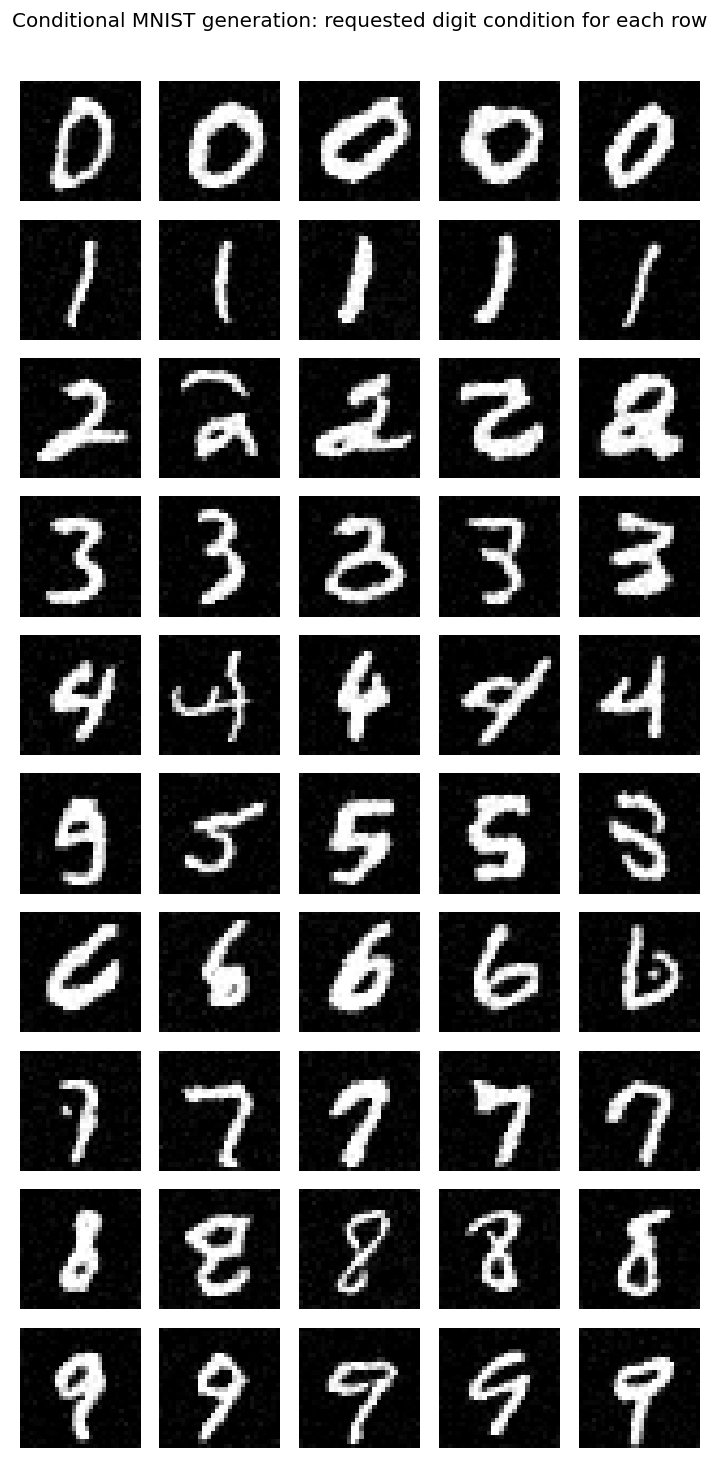

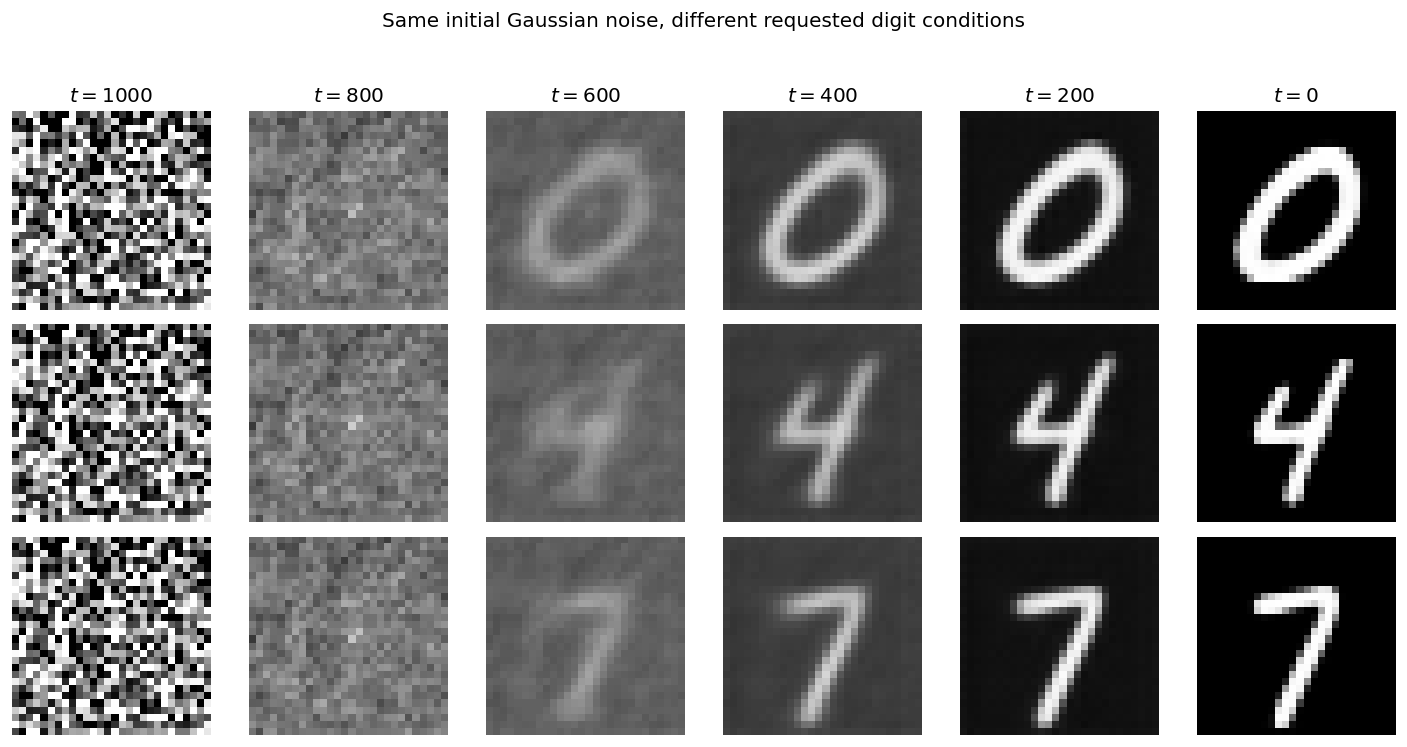

In [17]:
# ── 12. Run the learned conditional reverse SDE ───────────────────────────────

@torch.no_grad()
def generate_conditional_mnist(
    model: nn.Module,
    c_desired: torch.Tensor,
    xT_new: torch.Tensor,
    snapshot_times: list[int] | None = None,
    stochastic: bool = True,
) -> tuple[torch.Tensor, dict[int, torch.Tensor]]:
    """
    Generate MNIST images using the learned conditional reverse SDE.

    This follows the recipe-card update exactly:

        x_{t-1}
        =
        x_t
        +
        [0.5 beta_t x_t + beta_t s_theta(x_t, t, c_desired)] delta_t
        +
        sqrt(beta_t delta_t) epsilon_t

    Here:

        K = T_DIFF
        delta_t = 1

    Parameters
    ----------
    model
        Trained conditional score U-Net.

    c_desired
        Requested digit labels with shape:

            (batch_size,)

    xT_new
        Initial Gaussian noise with shape:

            (batch_size, 1, 28, 28)

    snapshot_times
        Optional diffusion times to save for visualization.
        For example:

            [1000, 800, 600, 400, 200, 0]

    stochastic
        When True, sample fresh reverse noise epsilon_t.

        When False, use epsilon_t = 0 at every step.
        This is useful for visualizing clean, condition-specific
        denoising trajectories.

    Returns
    -------
    x0_new
        Final generated images at t = 0.

    snapshots
        Dictionary mapping saved times to generated images.
    """
    model.eval()

    c_desired = c_desired.to(
        device=DEVICE,
        dtype=torch.long,
    ).view(-1)

    x = xT_new.to(DEVICE).clone()

    batch_size = x.shape[0]

    if x.shape != (batch_size, 1, 28, 28):
        raise ValueError(
            "xT_new must have shape "
            f"(batch_size, 1, 28, 28), but received {tuple(x.shape)}."
        )

    if c_desired.shape[0] != batch_size:
        raise ValueError(
            "c_desired and xT_new must have the same batch size."
        )

    if torch.any(c_desired < 0) or torch.any(c_desired >= N_CLASSES):
        raise ValueError(
            f"Each requested condition must be in {{0, ..., {N_CLASSES - 1}}}."
        )

    if snapshot_times is None:
        snapshot_times = []

    snapshot_times = set(snapshot_times)

    valid_snapshot_times = set(range(T_DIFF + 1))

    invalid_snapshot_times = snapshot_times - valid_snapshot_times

    if invalid_snapshot_times:
        raise ValueError(
            f"Invalid snapshot times: {sorted(invalid_snapshot_times)}"
        )

    snapshots = {}

    if T_DIFF in snapshot_times:
        snapshots[T_DIFF] = x.detach().cpu().clone()

    # t = T, T-1, ..., 1
    for t_value in range(T_DIFF, 0, -1):

        t_batch = torch.full(
            size=(batch_size,),
            fill_value=t_value,
            dtype=torch.long,
            device=DEVICE,
        )

        # 12.3 — Predict the conditional score.
        predicted_score = model(
            xt=x,
            t=t_batch,
            c=c_desired,
        )

        # beta_t corresponds to the forward transition:
        #
        #     x_{t-1} -> x_t
        #
        # BETAS has indices 0, ..., T_DIFF - 1,
        # therefore beta_t is stored at BETAS[t_value - 1].

        beta_t = BETAS[t_value - 1].to(DEVICE)

        # 12.2 — Sample reverse SDE noise.
        #
        # In the final step from t = 1 to t = 0,
        # use epsilon_t = 0.

        if stochastic and t_value > 1:
            epsilon_t = torch.randn_like(x)
        else:
            epsilon_t = torch.zeros_like(x)

        # 12.4 — One reverse Euler--Maruyama update.
        #
        # delta_t = 1 because K = T_DIFF.

        x = (
            x
            + (
                0.5 * beta_t * x
                + beta_t * predicted_score
            ) * DELTA_T
            + torch.sqrt(beta_t * DELTA_T) * epsilon_t
        )

        t_previous = t_value - 1

        if t_previous in snapshot_times:
            snapshots[t_previous] = x.detach().cpu().clone()

    return x, snapshots


# ── 12.1 Generate independent samples for every requested digit ───────────────

generated_grid, _ = generate_conditional_mnist(
    model=score_model,
    c_desired=desired_conditions_grid,
    xT_new=xT_grid,
    stochastic=True,
)

generated_grid = generated_grid.detach().cpu()


# ── Visualize generated digit grid ────────────────────────────────────────────

fig, axes = plt.subplots(
    N_CLASSES,
    SAMPLES_PER_DIGIT,
    figsize=(1.2 * SAMPLES_PER_DIGIT, 1.2 * N_CLASSES),
)

for digit in range(N_CLASSES):

    for sample_index in range(SAMPLES_PER_DIGIT):

        index = digit * SAMPLES_PER_DIGIT + sample_index

        axes[digit, sample_index].imshow(
            denormalize_mnist(generated_grid[index]).squeeze(),
            cmap="gray",
            vmin=0,
            vmax=1,
        )

        axes[digit, sample_index].axis("off")

    axes[digit, 0].set_ylabel(
        rf"$c_{{\mathrm{{desired}}}}={digit}$",
        rotation=0,
        labelpad=33,
        va="center",
    )

fig.suptitle(
    "Conditional MNIST generation: requested digit condition for each row",
    y=1.01,
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "conditional_mnist_generated_grid.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


# ── 12.2 Visualize denoising trajectories for selected conditions ─────────────
#
# The three trajectories start from exactly the same x_T.
#
# We set stochastic=False only for this visualization, so differences between
# trajectories come entirely from the requested condition c_desired.

trajectory_final, trajectory_snapshots = generate_conditional_mnist(
    model=score_model,
    c_desired=trajectory_conditions,
    xT_new=shared_xT,
    snapshot_times=SNAPSHOT_TIMES,
    stochastic=False,
)


fig, axes = plt.subplots(
    len(TRAJECTORY_DIGITS),
    len(SNAPSHOT_TIMES),
    figsize=(2.0 * len(SNAPSHOT_TIMES), 2.0 * len(TRAJECTORY_DIGITS)),
)

for row, digit in enumerate(TRAJECTORY_DIGITS):

    for col, t_value in enumerate(SNAPSHOT_TIMES):

        image_at_t = trajectory_snapshots[t_value][row]

        axes[row, col].imshow(
            denormalize_mnist(image_at_t).squeeze(),
            cmap="gray",
            vmin=0,
            vmax=1,
        )

        axes[row, col].axis("off")

        if row == 0:
            axes[row, col].set_title(rf"$t={t_value}$")

    axes[row, 0].set_ylabel(
        rf"$c_{{\mathrm{{desired}}}}={digit}$",
        rotation=0,
        labelpad=37,
        va="center",
    )

fig.suptitle(
    "Same initial Gaussian noise, different requested digit conditions",
    y=1.03,
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "conditional_mnist_denoising_trajectories.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()